## Keşifsel Veri Analizi(EDA)

Bu dosyada Online Retail verisi keşifsel veri analizi ile incelenmiş,
satış trendleri ve müşteri segmentlerinin gelir katkıları analiz edilmiştir.


## Ortam Kurulumu

Bu bölümde Google Drive bağlantısı kurulmuş ve proje dizinine
erişim sağlanmıştır. Analiz için gerekli kütüphaneler yüklenmiştir.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/online-retail-analysis')

import pandas as pd
import matplotlib.pyplot as plt


Mounted at /content/drive


## RFM Metriklerinin Hesaplanması

Bu bölümde müşteri bazlı Recency, Frequency ve Monetary metrikleri
hesaplanarak RFM tablosu oluşturulmuştur.


In [3]:
df = pd.read_csv('data/processed/cleaned_online_retail.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

today_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (today_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()


In [4]:
rfm = pd.read_csv('data/processed/rfm_table.csv')
rfm.set_index('CustomerID', inplace=True)

rfm.head()


,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,115
12347.0,2,7,4310.00,5,5,5,555
12348.0,75,4,1797.24,2,4,4,244
12349.0,19,1,1757.55,4,1,4,414
12350.0,310,1,334.40,1,1,2,112


## RFM Segmentasyonu

Bu bölümde RFM skorları kullanılarak müşteriler davranışlarına göre
segmentlere ayrılmıştır.


In [5]:
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

segment_map = {
    r'[4-5][4-5]': 'Champions',
    r'[3-4][3-5]': 'Loyal Customers',
    r'[4-5][1-3]': 'Potential Loyalists',
    r'5[1]': 'New Customers',
    r'3[1-2]': 'Promising',
    r'[2-3][2-3]': 'Need Attention',
    r'2[1-2]': 'About To Sleep',
    r'[1-2][3-5]': 'At Risk',
    r'1[4-5]': 'Cannot Lose',
    r'1[1-2]': 'Lost'
}

rfm['Segment'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str)
).replace(segment_map, regex=True)

rfm['Segment'].value_counts()


,count
Segment,
Champions,1139
Loyal Customers,685
Lost,664
Potential Loyalists,455
Need Attention,428
At Risk,417
Promising,351
About To Sleep,199


In [6]:
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Customer_Count']
segment_counts


,Segment,Customer_Count
0,Champions,1139
1,Loyal Customers,685
2,Lost,664
3,Potential Loyalists,455
4,Need Attention,428
5,At Risk,417
6,Promising,351
7,About To Sleep,199


## Segment Bazlı Müşteri Dağılımı

Bu görselleştirmede müşteri segmentlerinin sayısal dağılımı
incelenmiştir.


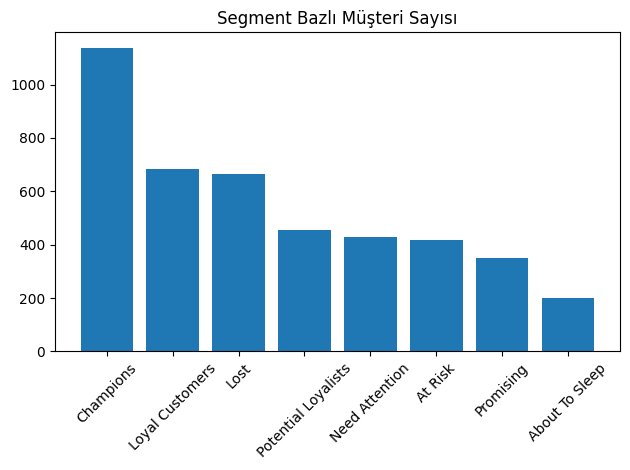

In [7]:
plt.figure()
plt.bar(segment_counts['Segment'], segment_counts['Customer_Count'])
plt.xticks(rotation=45)
plt.title('Segment Bazlı Müşteri Sayısı')
plt.tight_layout()
plt.show()


In [11]:
segment_counts['Percentage'] = (
    segment_counts['Customer_Count'] /
    segment_counts['Customer_Count'].sum() * 100
).round(2)

segment_counts


,Segment,Customer_Count,Percentage
0,Champions,1139,26.26
1,Loyal Customers,685,15.79
2,Lost,664,15.31
3,Potential Loyalists,455,10.49
4,Need Attention,428,9.87
5,At Risk,417,9.61
6,Promising,351,8.09
7,About To Sleep,199,4.59


## Segment Bazlı Toplam Ciro

Bu bölümde müşteri segmentlerinin toplam ciroya olan katkıları
hesaplanmıştır.


In [8]:
df = pd.read_csv('data/processed/cleaned_online_retail.csv')
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']


rfm_revenue = df.merge(
    rfm[['Segment']],
    left_on='CustomerID',
    right_index=True,
    how='inner'
)

segment_revenue = (
    rfm_revenue
    .groupby('Segment')['TotalPrice']
    .sum()
    .reset_index()
    .sort_values(by='TotalPrice', ascending=False)
)

segment_revenue


,Segment,TotalPrice
2,Champions,5927723.911
4,Loyal Customers,1082378.650
1,At Risk,604961.940
6,Potential Loyalists,419532.630
3,Lost,316163.991
5,Need Attention,305893.572
7,Promising,161832.590
0,About To Sleep,92920.620


## Görselleştirme

Her segmentin toplam ciro katkısı çubuk grafik ile gösterilmiştir.


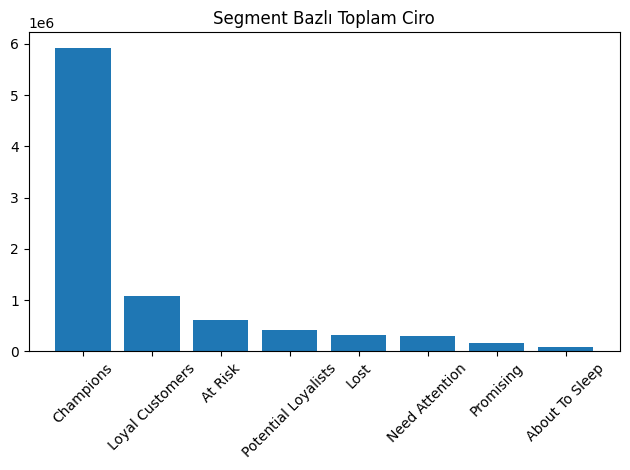

In [9]:
plt.figure()
plt.bar(segment_revenue['Segment'], segment_revenue['TotalPrice'])
plt.xticks(rotation=45)
plt.title('Segment Bazlı Toplam Ciro')
plt.tight_layout()
plt.show()


Segmentlerin sipariş sıklıkları karşılaştırılmıştır.


In [10]:
segment_orders = (
    rfm_revenue
    .groupby('Segment')['InvoiceNo']
    .nunique()
    .reset_index(name='Order_Count')
)

segment_orders


,Segment,Order_Count
0,About To Sleep,199
1,At Risk,1657
2,Champions,11375
3,Lost,707
4,Loyal Customers,2671
5,Need Attention,799
6,Potential Loyalists,716
7,Promising,408


Her müşteri segmenti için ortalama sipariş tutarı (Average Order Value) ve benzersiz sipariş sayısı hesaplanmıştır.


In [ ]:
rfm = rfm.reset_index()

segment_avg_basket = (
    df_segmented
    .groupby('Segment')
    .agg(
        avg_order_value=('TotalPrice', 'mean'),
        order_count=('InvoiceNo', 'nunique')
    )
    .reset_index()
)

segment_avg_basket


,Segment,avg_order_value,order_count
0,About To Sleep,19.091970,199
1,At Risk,22.174399,1657
2,Champions,23.700278,11375
3,Lost,24.097865,707
4,Loyal Customers,18.685541,2671
5,Need Attention,19.149466,799
6,Potential Loyalists,23.009523,716
7,Promising,15.605843,408


En değerli müşteri grubu (Champions) ile kaybedilme riski taşıyan müşteriler (At Risk) temel performans metrikleri üzerinden karşılaştırılmıştır.


In [ ]:
key_segments = ['Champions', 'At Risk']

comparison = (
    df_segmented[df_segmented['Segment'].isin(key_segments)]
    .groupby('Segment')
    .agg(
        customer_count=('CustomerID', 'nunique'),
        total_revenue=('TotalPrice', 'sum'),
        avg_basket=('TotalPrice', 'mean')
    )
    .reset_index()
)

comparison


,Segment,customer_count,total_revenue,avg_basket
0,At Risk,417,604961.940,22.174399
1,Champions,1139,5927723.911,23.700278


## Aksiyon Önceliklendirmesi

- Champions: Yüksek değerli müşteriler olduğu için sadakat ve özel kampanyalarla elde tutulmalıdır.
- Loyal Customers: Düzenli alışveriş yapan bu grup için çapraz satış ve ürün önerileri uygulanabilir.
- At Risk: Geçmişte değerli olan ancak son dönemde pasifleşen müşteriler için geri kazanım kampanyaları önerilmektedir.
- Lost: Pazarlama maliyeti yüksek olacağından düşük öncelikli segment olarak değerlendirilmiştir.
